In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')

In [3]:
df = pd.read_csv('../data/marketing_campaign.csv', sep='\t')

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [4]:
print("Shape:", df.shape)

df.info()

Shape: (2240, 29)
<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-n

In [5]:
df.isnull().sum().sort_values(ascending=False)

Income                 24
ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [6]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,2240.0,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,1968.805804,11.984069,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.251354,25173.076661,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0


In [8]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

print("\nCategorical Columns:")
print(df.select_dtypes(include='object').columns.tolist())

print("\nNumerical Columns:")
print(df.select_dtypes(exclude='object').columns.tolist())

Rows: 2240
Columns: 29

Categorical Columns:
['Education', 'Marital_Status', 'Dt_Customer']

Numerical Columns:
['ID', 'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']


In [9]:
df['Income'].fillna(df['Income'].median(), inplace=True)

print(df.isnull().sum().sum())

24


In [10]:
drop_cols = [
    'ID',
    'Dt_Customer',
    'Z_CostContact',
    'Z_Revenue'
]

df = df.drop(columns=drop_cols)

In [11]:
current_year = 2026

df['Age'] = current_year - df['Year_Birth']

df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age
0,1957,Graduation,Single,58138.0,0,0,58,635,88,546,...,4,7,0,0,0,0,0,0,1,69
1,1954,Graduation,Single,46344.0,1,1,38,11,1,6,...,2,5,0,0,0,0,0,0,0,72
2,1965,Graduation,Together,71613.0,0,0,26,426,49,127,...,10,4,0,0,0,0,0,0,0,61
3,1984,Graduation,Together,26646.0,1,0,26,11,4,20,...,4,6,0,0,0,0,0,0,0,42
4,1981,PhD,Married,58293.0,1,0,94,173,43,118,...,6,5,0,0,0,0,0,0,0,45


In [12]:
df_encoded = pd.get_dummies(
    df,
    columns=['Education', 'Marital_Status'],
    drop_first=True
)

df_encoded.head()

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
0,1957,58138.0,0,0,58,635,88,546,172,88,...,True,False,False,False,False,False,True,False,False,False
1,1954,46344.0,1,1,38,11,1,6,2,1,...,True,False,False,False,False,False,True,False,False,False
2,1965,71613.0,0,0,26,426,49,127,111,21,...,True,False,False,False,False,False,False,True,False,False
3,1984,26646.0,1,0,26,11,4,20,10,3,...,True,False,False,False,False,False,False,True,False,False
4,1981,58293.0,1,0,94,173,43,118,46,27,...,False,False,True,False,False,True,False,False,False,False


In [13]:
print(df_encoded.shape)

(2240, 35)


In [14]:
features = df_encoded.columns

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df_encoded)

scaled_df = pd.DataFrame(
    scaled_data,
    columns=features
)

scaled_df.head()

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
0,-0.985345,0.234063,-0.825218,-0.929894,0.307039,0.983781,1.551577,1.679702,2.462147,1.476500,...,0.993769,-0.444816,-0.526385,-0.036621,-0.339909,-0.792406,1.914854,-0.591099,-0.188676,-0.029894
1,-1.235733,-0.234559,1.032559,0.906934,-0.383664,-0.870479,-0.636301,-0.713225,-0.650449,-0.631503,...,0.993769,-0.444816,-0.526385,-0.036621,-0.339909,-0.792406,1.914854,-0.591099,-0.188676,-0.029894
2,-0.317643,0.769478,-0.825218,-0.929894,-0.798086,0.362723,0.570804,-0.177032,1.345274,-0.146905,...,0.993769,-0.444816,-0.526385,-0.036621,-0.339909,-0.792406,-0.522233,1.691765,-0.188676,-0.029894
3,1.268149,-1.017239,1.032559,-0.929894,-0.798086,-0.870479,-0.560857,-0.651187,-0.503974,-0.583043,...,0.993769,-0.444816,-0.526385,-0.036621,-0.339909,-0.792406,-0.522233,1.691765,-0.188676,-0.029894
4,1.017761,0.240221,1.032559,-0.929894,1.550305,-0.389085,0.419916,-0.216914,0.155164,-0.001525,...,-1.006270,-0.444816,1.899751,-0.036621,-0.339909,1.261980,-0.522233,-0.591099,-0.188676,-0.029894


In [15]:
scaled_df.describe().T[['mean', 'std']].head()

,mean,std
Year_Birth,-8.133970e-15,1.000223
Income,4.889791e-17,1.000226
Kidhome,-1.586033e-17,1.000223
Teenhome,-3.172066e-18,1.000223
Recency,-3.172066e-18,1.000223


In [20]:
df['Income'] = df['Income'].fillna(df['Income'].median())

print(df['Income'].isnull().sum())

0


In [24]:
df['Income'] = df['Income'].fillna(df['Income'].median())

current_year = 2026
df['Age'] = current_year - df['Year_Birth']

In [25]:
df_encoded = pd.get_dummies(
    df,
    columns=['Education', 'Marital_Status'],
    drop_first=True
)

In [26]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df_encoded)

scaled_df = pd.DataFrame(
    scaled_data,
    columns=df_encoded.columns
)

In [27]:
print("NaNs in df_encoded:", df_encoded.isnull().sum().sum())
print("NaNs in scaled_df:", scaled_df.isnull().sum().sum())

NaNs in df_encoded: 0
NaNs in scaled_df: 0


In [28]:
pca = PCA()

pca.fit(scaled_df)

explained_variance = pca.explained_variance_ratio_

print(explained_variance[:10])

[0.18790079 0.07609368 0.0566341  0.04818319 0.04412315 0.04170034
 0.0389954  0.03588459 0.03476104 0.03207882]


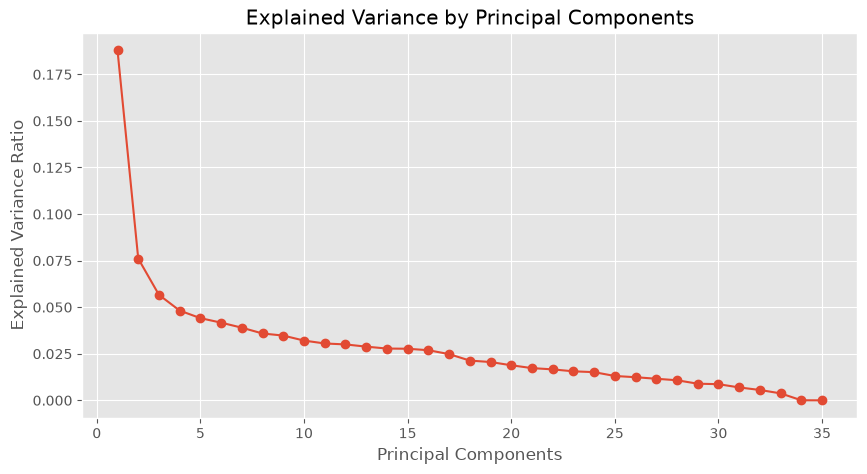

In [29]:
plt.figure(figsize=(10,5))

plt.plot(
    range(1, len(explained_variance)+1),
    explained_variance,
    marker='o'
)

plt.xlabel("Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance by Principal Components")

plt.show()

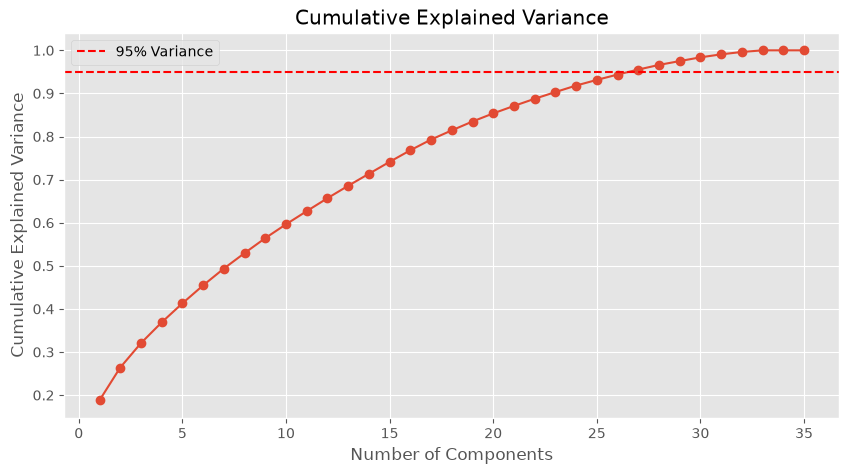

In [30]:
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(10,5))

plt.plot(
    range(1, len(cumulative_variance)+1),
    cumulative_variance,
    marker='o'
)

plt.axhline(
    y=0.95,
    color='red',
    linestyle='--',
    label='95% Variance'
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")

plt.title("Cumulative Explained Variance")

plt.legend()

plt.show()

In [31]:
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print("Components needed for 95% variance:")
print(n_components_95)

Components needed for 95% variance:
27


In [32]:
pca_final = PCA(n_components=n_components_95)

pca_data = pca_final.fit_transform(scaled_df)

print("Original Shape:", scaled_df.shape)
print("PCA Shape:", pca_data.shape)

Original Shape: (2240, 35)
PCA Shape: (2240, 27)


In [33]:
wcss = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(pca_data)

    wcss.append(kmeans.inertia_)

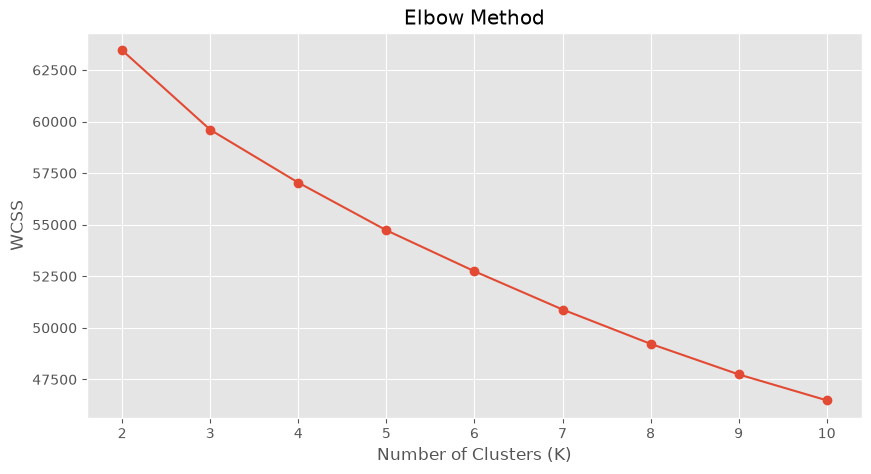

In [34]:
plt.figure(figsize=(10,5))

plt.plot(
    range(2,11),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

In [35]:
silhouette_scores = []

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(pca_data)

    score = silhouette_score(
        pca_data,
        labels
    )

    silhouette_scores.append(score)

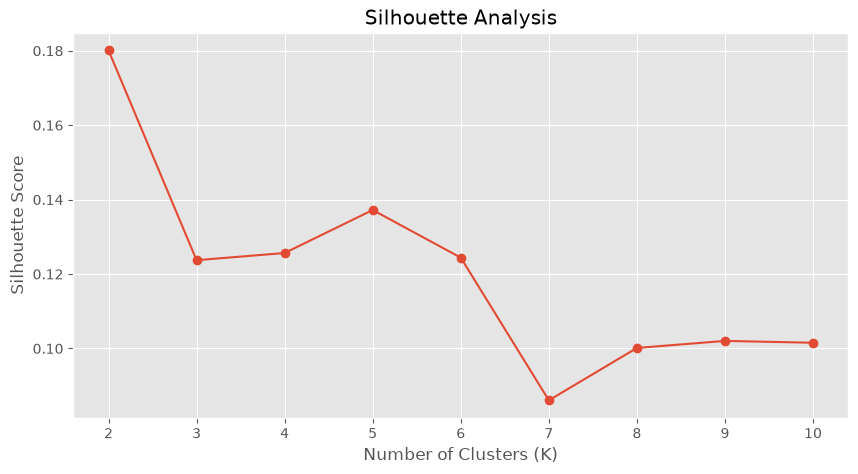

In [36]:
plt.figure(figsize=(10,5))

plt.plot(
    range(2,11),
    silhouette_scores,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")

plt.show()

In [37]:
for k, score in zip(range(2,11), silhouette_scores):
    print(f"K={k}: {score:.4f}")

K=2: 0.1801
K=3: 0.1237
K=4: 0.1257
K=5: 0.1372
K=6: 0.1244
K=7: 0.0861
K=8: 0.1001
K=9: 0.1020
K=10: 0.1015


In [38]:
optimal_k = 5

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(pca_data)

df['Cluster'] = clusters

In [39]:
df['Cluster'].value_counts().sort_index()

Cluster
0     54
1    933
2    590
3    480
4    183
Name: count, dtype: int64

In [40]:
pca_2d = PCA(n_components=2)

pca_2d_data = pca_2d.fit_transform(scaled_df)

plot_df = pd.DataFrame(
    pca_2d_data,
    columns=['PC1', 'PC2']
)

plot_df['Cluster'] = clusters

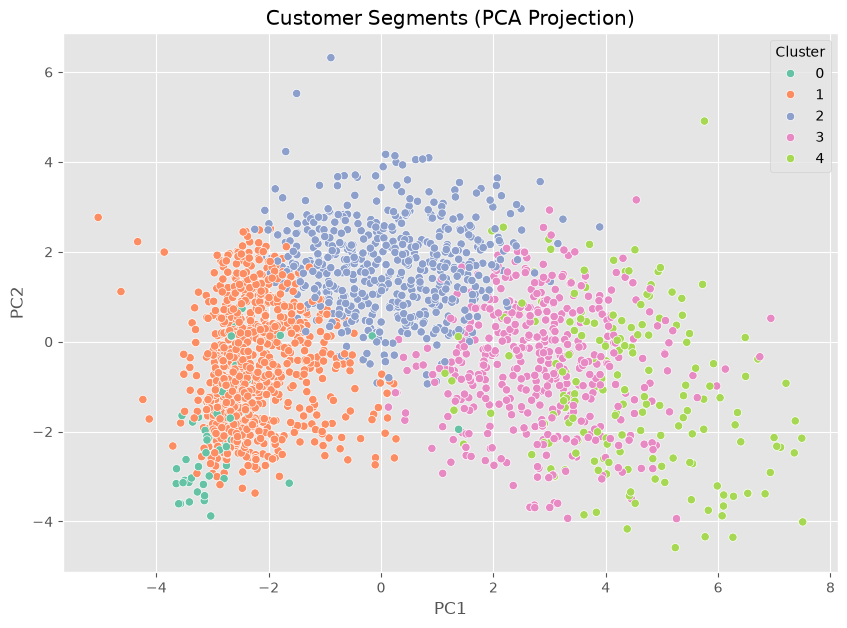

In [41]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=plot_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set2'
)

plt.title('Customer Segments (PCA Projection)')
plt.show()

In [42]:
cluster_profile = df.groupby('Cluster').mean(numeric_only=True)

cluster_profile

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age
Cluster,,,,,,,,,,,,,,,,,,,,,
0,1977.462963,20306.259259,0.629630,0.092593,48.444444,7.240741,11.111111,11.444444,17.055556,12.111111,...,2.851852,6.870370,0.111111,0.000000,0.000000,0.000000,0.000000,0.000000,0.037037,48.537037
1,1972.918542,34981.571811,0.843516,0.422294,49.566988,42.688103,5.371919,25.596999,7.404073,5.145766,...,3.228296,6.532690,0.073955,0.005359,0.000000,0.001072,0.002144,0.012862,0.096463,53.081458
2,1961.688136,56460.497458,0.228814,0.969492,47.693220,417.259322,15.440678,112.581356,22.155932,15.661017,...,7.147458,5.745763,0.061017,0.132203,0.003390,0.032203,0.010169,0.006780,0.110169,64.311864
3,1968.281250,73061.422917,0.062500,0.289583,50.212500,489.191667,70.781250,409.522917,101.370833,70.993750,...,8.508333,3.116667,0.047917,0.031250,0.000000,0.079167,0.000000,0.008333,0.141667,57.718750
4,1969.606557,81407.344262,0.049180,0.131148,48.644809,872.142077,55.846995,472.535519,79.224044,64.748634,...,8.213115,3.043716,0.158470,0.377049,0.879781,0.469945,0.120219,0.005464,0.595628,56.393443


In [43]:
cluster_profile[['Income',
                 'Age',
                 'MntWines',
                 'MntMeatProducts',
                 'NumStorePurchases',
                 'NumWebPurchases']]

,Income,Age,MntWines,MntMeatProducts,NumStorePurchases,NumWebPurchases
Cluster,,,,,,
0,20306.259259,48.537037,7.240741,11.444444,2.851852,1.888889
1,34981.571811,53.081458,42.688103,25.596999,3.228296,2.169346
2,56460.497458,64.311864,417.259322,112.581356,7.147458,5.855932
3,73061.422917,57.718750,489.191667,409.522917,8.508333,5.352083
4,81407.344262,56.393443,872.142077,472.535519,8.213115,5.464481


In [44]:
cluster_profile.to_csv(
    '../outputs/cluster_profiles.csv'
)

print("Cluster profile exported.")

Cluster profile exported.


In [45]:
cluster_profile[['Income',
                 'Age',
                 'MntWines',
                 'MntMeatProducts',
                 'MntFishProducts',
                 'MntSweetProducts',
                 'NumStorePurchases',
                 'NumWebPurchases',
                 'NumCatalogPurchases',
                 'NumDealsPurchases',
                 'NumWebVisitsMonth']]

,Income,Age,MntWines,MntMeatProducts,MntFishProducts,MntSweetProducts,NumStorePurchases,NumWebPurchases,NumCatalogPurchases,NumDealsPurchases,NumWebVisitsMonth
Cluster,,,,,,,,,,,
0,20306.259259,48.537037,7.240741,11.444444,17.055556,12.111111,2.851852,1.888889,0.481481,1.796296,6.870370
1,34981.571811,53.081458,42.688103,25.596999,7.404073,5.145766,3.228296,2.169346,0.544480,2.113612,6.532690
2,56460.497458,64.311864,417.259322,112.581356,22.155932,15.661017,7.147458,5.855932,2.754237,3.649153,5.745763
3,73061.422917,57.718750,489.191667,409.522917,101.370833,70.993750,8.508333,5.352083,5.610417,1.652083,3.116667
4,81407.344262,56.393443,872.142077,472.535519,79.224044,64.748634,8.213115,5.464481,6.071038,1.054645,3.043716


In [46]:
cluster_profile['Age'] = 2026 - cluster_profile['Year_Birth']

cluster_profile[['Age',
                 'Income',
                 'NumStorePurchases',
                 'NumWebPurchases',
                 'NumCatalogPurchases',
                 'NumDealsPurchases']]

,Age,Income,NumStorePurchases,NumWebPurchases,NumCatalogPurchases,NumDealsPurchases
Cluster,,,,,,
0,48.537037,20306.259259,2.851852,1.888889,0.481481,1.796296
1,53.081458,34981.571811,3.228296,2.169346,0.544480,2.113612
2,64.311864,56460.497458,7.147458,5.855932,2.754237,3.649153
3,57.718750,73061.422917,8.508333,5.352083,5.610417,1.652083
4,56.393443,81407.344262,8.213115,5.464481,6.071038,1.054645


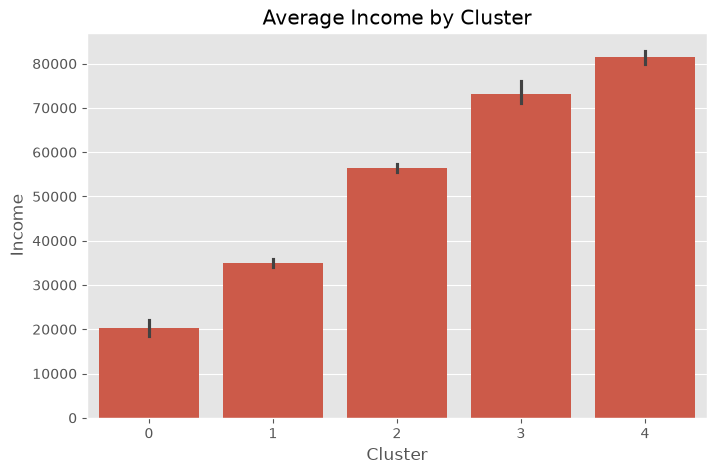

In [47]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=df['Cluster'],
    y=df['Income']
)

plt.title("Average Income by Cluster")
plt.show()

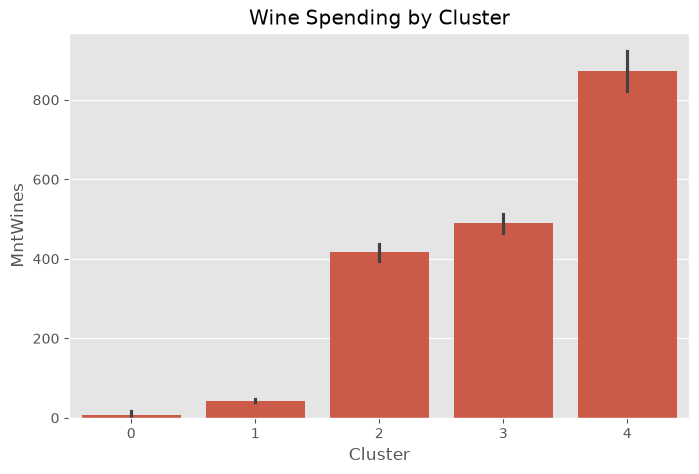

In [48]:
    plt.figure(figsize=(8,5))

sns.barplot(
    x=df['Cluster'],
    y=df['MntWines']
)

plt.title("Wine Spending by Cluster")
plt.show()

In [49]:
df['Total_Spending'] = (
    df['MntWines']
    + df['MntFruits']
    + df['MntMeatProducts']
    + df['MntFishProducts']
    + df['MntSweetProducts']
    + df['MntGoldProds']
)

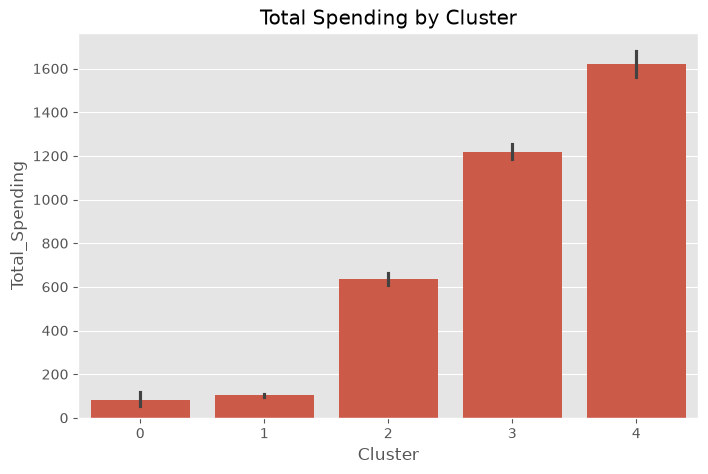

In [50]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Cluster',
    y='Total_Spending',
    data=df
)

plt.title("Total Spending by Cluster")
plt.show()

In [51]:
persona_summary = pd.DataFrame({
    "Persona": [
        "Low-Value At-Risk Customers",
        "Budget-Conscious Shoppers",
        "Mature Value Buyers",
        "Premium Loyal Customers",
        "Elite High-Value Customers"
    ]
})

persona_summary

,Persona
0,Low-Value At-Risk Customers
1,Budget-Conscious Shoppers
2,Mature Value Buyers
3,Premium Loyal Customers
4,Elite High-Value Customers


In [52]:
cluster_profile.index.name = "Cluster"

cluster_profile.to_csv(
    '../outputs/cluster_profiles.csv'
)

In [53]:
df.to_csv(
    '../outputs/customer_segments.csv',
    index=False
)

In [54]:
df.to_csv('../outputs/customer_segments.csv', index=False)

Conclusion

Using PCA and K-Means Clustering, customer purchasing behavior was segmented into five distinct groups. PCA reduced the dimensionality of the dataset while preserving 95% of the original variance. The Elbow Method and Silhouette Analysis were used to determine an appropriate number of clusters.

The analysis identified customer groups ranging from low-value at-risk customers to elite high-value customers. These segments provide actionable business insights that can help organizations improve customer retention, optimize marketing campaigns, personalize recommendations, and maximize revenue.
